# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## 0.Setup

Import packages required for the analysis

In [57]:
import sys
from os.path import join, expanduser
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
from tqdm import tqdm

In [58]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [59]:
# Raster
import rasterio as rio
import numpy as np
from shapely.geometry import Polygon, box, Point
import skimage.graph as graph

# Graph
import pickle
import networkx as nx
import osmnx as ox

In [60]:
# Climate/Flood

import xarray as xr

In [61]:
# Define your path to the Repositories

sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

In [62]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define below the local folder where you are located

In [63]:
scratch_dir = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics')

## 1. Data Preparation

### Administrative boundaries

In [64]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)

<Axes: >

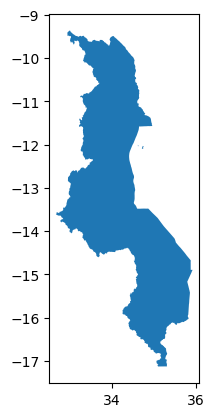

In [65]:
adm0.plot()

### Population (origin)

In [66]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020', f'ppp_2020_1km_Aggregated.tif') # Download from link above

wp_rio = rio.open(wp_path)
pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [67]:
hf_path = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics', 'data', 'MWI', 'HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)
df_hf

,Facility Name,Village,GVH,TA,District,Region,Eastings,Northings,Datum,Facility Type,Controlling Agency,Name,Phone,Email,Cluster,Status,Date
0,CHITIPA DH,Mkombanyama,Mkombanyama,Mwawulambya,Chitipa,North,33.265889,-9.701577,WGS 84,Hospital,MoH,Dzinkambani Kambalame,991183141,dzinkambalame@gmail.com,Chitipa DH,Functional,2016-07-01
1,NGOYA,Mphala,Mwakawanga,Mwawulambya,Chitipa,North,33.293329,-9.617792,WGS 84,Health Post,MoH,Martha Mwanza,884254076,NaN,Chitipa DH,Functional,2016-07-01
2,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Outreach,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
3,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Village Clinic,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
4,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Health Post,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,MLOLO,Chipondeni,Chipondeni,Mlolo,Nsanje,South,35.152560,-16.419711,WGS 84,Health Post,MoH,Charlie Mateyu,881148416,NaN,Mlolo,Functional,2016-09-01
9494,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Outreach,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9495,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Village Clinic,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9496,KANDODO,Gowoke,Gowoke,Mlolo,Nsanje,South,35.159567,-16.405433,WGS 84,Outreach,MoH,Charity Bramu,888595161,NaN,Mlolo,Functional,2016-09-01


In [68]:
hf_type = list(df_hf['Facility Type'].unique())
print(hf_type)

['Hospital', 'Health Post', 'Outreach', 'Village Clinic', 'Health Centre', 'Dispensary']


#### Subset a Health Facility type 

In [69]:
facility = 'Hospital'
df_hf = df_hf.loc[df_hf['Facility Type'] == facility]

Convert the HF from pandas.Dataframe to Geopandas.dataframe

In [70]:
geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs="EPSG:4326"
)

Clean the Geopandas df

In [71]:
geodf_hf = geodf_hf[['Facility Name', 'geometry']]
geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf


,Facility Name,geometry,ID
0,CHITIPA DH,POINT (33.26589 -9.70158),0
214,KARONGA DH,POINT (33.91076 -9.95506),214
367,CHILUMBA,POINT (34.25147 -10.43240),367
442,ATUPELE,POINT (33.83755 -9.73631),442
458,KAPORO,POINT (33.87465 -9.76753),458
...,...,...,...
9061,MONTFORT,POINT (34.86908 -16.25632),9061
9229,NGABU,POINT (34.89222 -16.45934),9229
9272,NSANJE DH,POINT (35.25995 -16.91768),9272
9398,KALEMBA,POINT (35.11150 -16.57579),9398


### Flood

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [72]:
# Define which Flood Return Time to consider for the analysis

import ipywidgets as widgets

flood_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended')
w = widgets.Dropdown(
    options = os.listdir(flood_path),
    description='Flood RT:',
    value = 'FU_1in5.tif',
    disabled=False,
)

display('Select the Flood Return Period to perform the analysis:')
display(w)

'Select the Flood Return Period to perform the analysis:'

Dropdown(description='Flood RT:', index=6, options=('FU_1in10.tif', 'FU_1in100.tif', 'FU_1in1000.tif', 'FU_1in…

In [73]:
# Use rasterio to open the file
# inland waters and oceans: 999
# not-flooded areas: -9999
# Other values represent the flood depth (in  m)

flood_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended', w.value)
flood_rio = rio.open(flood_path)

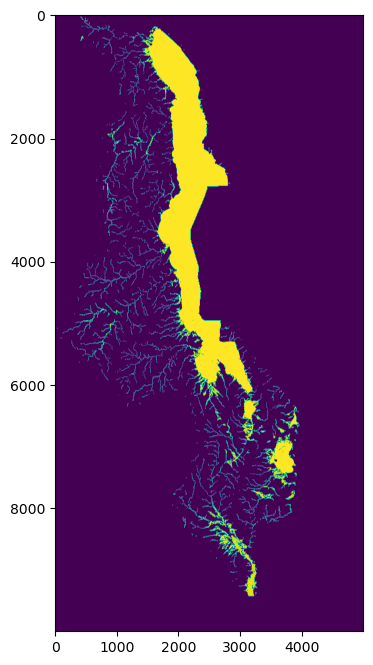

In [74]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(flood_rio.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

In [75]:
# Import multiple rasterio .tif file as list

# import os 

# flood_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended')
# files=os.listdir(flood_path)

# flood_rio = []
# for file in files:
#     content = rio.open(join(flood_path,file))
#     flood_rio.append(content)

In [76]:
# Stack flood maps into a single rasterio multiband file

# # Read metadata of first file
# with rio.open(join(flood_path,files[0])) as src0:
#     meta = src0.meta

# # Update meta to reflect the number of layers
# meta.update(count = len(files))

# # Read each layer and write it to stack
# with rio.open('stack.tif', 'w', **meta) as dst:
#     for id, file in enumerate(files, start=1):
#         with rio.open(join(flood_path,file)) as src1:
#             dst.write_band(id, src1.read(1))

# flood_path = join(scratch_dir, 'notebooks', 'stack.tif')
# flood_rio = rio.open(flood_path)


### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [77]:
# # Only the first time, clip the travel friction surface to the country of interest

# gfs_path = join(expanduser("R:/"), 'Data', 'GLOBAL/INFRA/FRICTION_2020', '2020_motorized_friction_surface.geotiff') # Download from link above
# gfs_rio = rio.open(gfs_path)
# out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
# rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

In [78]:
# Import the clipped friction surface

out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
travel_surf = rio.open(out_travel_surface)
travel_surf

<open DatasetReader name='C:/Users/wb618081/OneDrive - WBG/Health-Access-Metrics/data/travel_surface_motorized_MWI.tif' mode='r'>

In [79]:
travel_surf.index

<bound method TransformMethodsMixin.index of <open DatasetReader name='C:/Users/wb618081/OneDrive - WBG/Health-Access-Metrics/data/travel_surface_motorized_MWI.tif' mode='r'>>

In [80]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


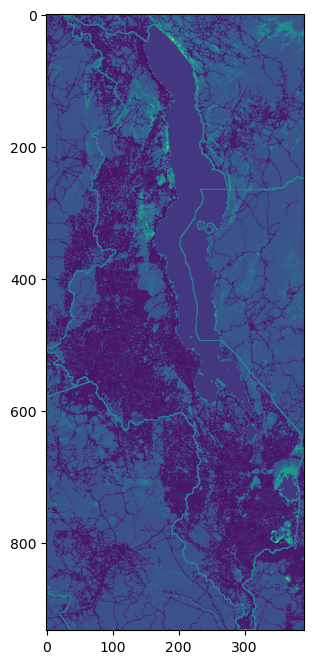

In [81]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(travel_surf.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

In [82]:
travel_surf.read(1)

array([[0.0015    , 0.0015    , 0.01467985, ..., 0.01306348, 0.0129127 ,
        0.01326628],
       [0.0015    , 0.01647647, 0.01546028, ..., 0.01296942, 0.01338315,
        0.01342822],
       [0.01745253, 0.01748244, 0.01728696, ..., 0.01341866, 0.01349515,
        0.0138922 ],
       ...,
       [0.01391766, 0.0133115 , 0.0138313 , ..., 0.01519449, 0.0128843 ,
        0.01306937],
       [0.01350729, 0.01378031, 0.01399023, ..., 0.01387159, 0.01338546,
        0.01344095],
       [0.01385168, 0.01392184, 0.01331453, ..., 0.01317562, 0.01329797,
        0.01306588]], dtype=float32)

Align the population raster to the friction surface, ensuring that they have the same extent and resolution.

In [83]:
out_pop_surface_std = join(scratch_dir, 'data', "WP_2020_1km_STD_test.tif")
rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

[array([[[67.61455  , 70.83097  , 96.48191  , ...,  4.846376 ,
           7.727382 ,  7.5541716],
         [61.91576  , 62.618916 , 77.278244 , ...,  2.8063774,
           6.704942 ,  7.74414  ],
         [53.38135  , 55.781017 , 64.322914 , ...,  1.6051795,
           4.2656183,  4.0875587],
         ...,
         [32.477394 , 28.508108 , 25.174734 , ..., 15.47292  ,
          14.119669 , 12.792173 ],
         [30.201307 , 31.671202 , 31.06995  , ..., 16.121716 ,
          14.633034 , 13.378336 ],
         [33.76848  , 32.88883  , 32.243195 , ..., 14.960836 ,
          14.153514 , 13.6319685]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': -3.4028234663852886e+38,
  'width': 390,
  'height': 933,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 32.66666666666666,
         0.0, -0.008333333333333333, -9.358333333333334)}]

Align the Flood raster to the friction surface, ensuring that they have the same extent and resolution.

In [85]:
out_flood_std = join(scratch_dir, 'data', "STD_" + w.value)
rMisc.standardizeInputRasters(flood_rio, travel_surf, out_flood_std, resampling_type="nearest")

[array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': None,
  'width': 390,
  'height': 933,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 32.66666666666666,
         0.0, -0.008333333333333333, -9.358333333333334)}]

### Origins

We prepare a standard grid using each cell from the 1km World Pop raster.

In [29]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)
pop_surf.read_crs()

CRS.from_epsg(4326)

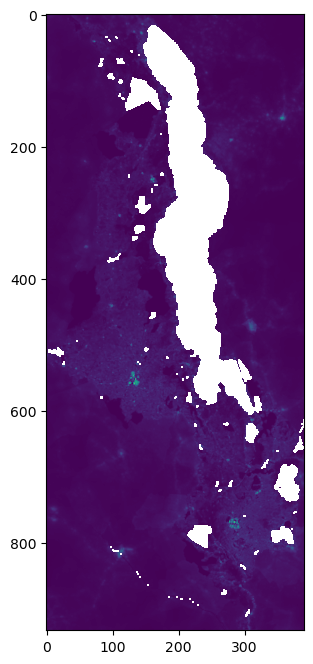

In [30]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

In [31]:
pop_surf.xy(0,0)

(32.67083333333333, -9.3625)

In [32]:
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4
...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868


### Flood impact on Friction Surface

In [33]:
flood_rio = rio.open(out_flood_std)
display(flood_rio.read_crs())
flood_rio = flood_rio.read(1, masked=False)

CRS.from_epsg(4326)

We consider different degrees of accessibility/mobility disruption according to different flood depth (FD) levels

- If the FD is less than 0.3 meters, than accessibility is preserved but signifcantly impacted (slowered)
- If the FD is higher than 0.3 meters, than mobility is interrupted on that specific pathway 

In [34]:
# Create weights for the Friction Surface
# If water level is less than 30 cm, accessibility is halved 
# If water level is more than 30 cm, accessibility is disrupted

flood_rio_fd = flood_rio.copy()

flood_rio_fd[(flood_rio <= 0) | (flood_rio == 999)] = 1
flood_rio_fd[(flood_rio > 0) & (flood_rio < 0.3)] = 0.5
flood_rio_fd[(flood_rio >= 0.3) & (flood_rio < 999)] = 0

# Check flood weight values
np.unique(flood_rio_fd)

array([0. , 0.5, 1. ], dtype=float32)

In [35]:
# Weight the Friction Surface with the discrete flood depth array

travel_surf_flood = travel_surf.read(1) * flood_rio_fd

Create an MCP graph object from the friction surface.

In [37]:
# convert friction surface to traversal time (lazily). Original data are minutes to travel 1 m:
# We convert it to minutes to cross the cell (1000m). This could be revised

inG_data = travel_surf_flood * 1000

# Correct no data values. Not needed but good to check
# inG_data[inG_data < 0] = 99999999
# inG_data[inG_data < 0] = np.nan
mcp = graph.MCP_Geometric(inG_data)

In [38]:
print(f"Mean: {np.mean(inG_data)}")
print(f"Max: {np.max(inG_data)}")
print(f"Min: {np.min(inG_data)}")
print(f"Std: {np.std(inG_data)}")

Mean: 10.444897651672363
Max: 205.40260314941406
Min: 0.0
Std: 10.870339393615723


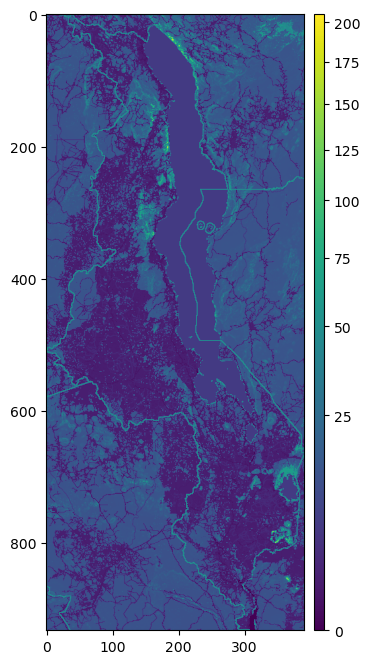

In [39]:
# Plot the Travel Time surface

copy = inG_data.copy()
copy[copy<0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')

## 2. Data analysis

In [40]:
len(res_df), len(geodf_hf)

(363870, 85)

Calculate the travel time from each grid-cell to the nearest destination

In [41]:
res = ma.calculate_travel_time(travel_surf, mcp, geodf_hf)[0]
res

array([[ 184.57579296,  183.07579296,  174.98586815, ..., 1073.34956356,
        1086.3376555 , 1099.42714448],
       [ 185.1971133 ,  192.06402939,  178.86201815, ..., 1070.3428781 ,
        1083.51916623, 1096.92485213],
       [ 194.67338016,  193.64747589,  176.26277321, ..., 1065.24557842,
        1078.70247997, 1092.39615263],
       ...,
       [ 467.89505936,  454.28047635,  445.75496626, ...,  209.28020612,
         211.10419905,  222.44061963],
       [ 462.50430844,  448.86050627,  434.97523377, ...,  223.81324331,
         224.23908007,  229.71896026],
       [ 458.83065196,  444.94388934,  431.32569953, ...,  237.33684913,
         237.58079827,  242.94300243]])

In [42]:
len(res.flatten()), len(res_df)

(363870, 363870)

In [43]:
res_df.loc[:, 'tt_hf_min'] = res.flatten()
res_df

,spatial_index,xy,pop,pointid,tt_hf_min
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0,184.575793
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1,183.075793
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2,174.985868
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3,166.895943
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4,165.395943
...,...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865,239.532932
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866,238.658006
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867,237.336849
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868,237.580798


In [44]:
# remove values where pop is 0 or nan
res_df = res_df.loc[res_df['pop']!=0].copy()
res_df = res_df.loc[~(res_df['pop'].isna())].copy()

In [45]:
res_df.loc[:,'xy'] = res_df.loc[:,'xy'].apply(lambda x: Point(x))

Create Geodataframe for the population grid

In [46]:
origins = gpd.GeoDataFrame(res_df, geometry='xy', crs='EPSG:4326')
origins

,spatial_index,xy,pop,pointid,tt_hf_min
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,184.575793
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,183.075793
2,"(0, 2)",POINT (32.68750 -9.36250),96.481911,2,174.985868
3,"(0, 3)",POINT (32.69583 -9.36250),111.579651,3,166.895943
4,"(0, 4)",POINT (32.70417 -9.36250),161.928329,4,165.395943
...,...,...,...,...,...
363865,"(932, 385)",POINT (35.87917 -17.12917),32.535667,363865,239.532932
363866,"(932, 386)",POINT (35.88750 -17.12917),24.958359,363866,238.658006
363867,"(932, 387)",POINT (35.89583 -17.12917),14.960836,363867,237.336849
363868,"(932, 388)",POINT (35.90417 -17.12917),14.153514,363868,237.580798


In [47]:
origins.rename(columns={'xy':'geometry'}, inplace=True)
origins.set_geometry('geometry', inplace=True)

In [48]:
# convert travel time to hours
origins.loc[:, "tt_hf_min_hrs"] = origins.loc[:, "tt_hf_min"] / 60

In [49]:
origins.head(2)

,spatial_index,geometry,pop,pointid,tt_hf_min,tt_hf_min_hrs
0,"(0, 0)",POINT (32.67083 -9.36250),67.614548,0,184.575793,3.076263
1,"(0, 1)",POINT (32.67917 -9.36250),70.830971,1,183.075793,3.051263


In [50]:
origins.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Save results as raster

In [51]:
# tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_{facility}.tif")
tt_raster = join(scratch_dir, f"tt_hf_min_motorized_friction_flood_100.tif")

In [52]:
rMisc.rasterizeDataFrame(
    inD = origins,
    outFile = tt_raster,
    idField = 'tt_hf_min_hrs',
    templateRaster = out_travel_surface
)

## Map Results

In [54]:
tt_rio = rio.open(tt_raster)
tt_rio

<open DatasetReader name='C:/Users/wb618081/OneDrive - WBG/Health-Access-Metrics/tt_hf_min_motorized_friction_flood_100.tif' mode='r'>

Text(0.85, 0.76, 'Travel Time (hrs.)')

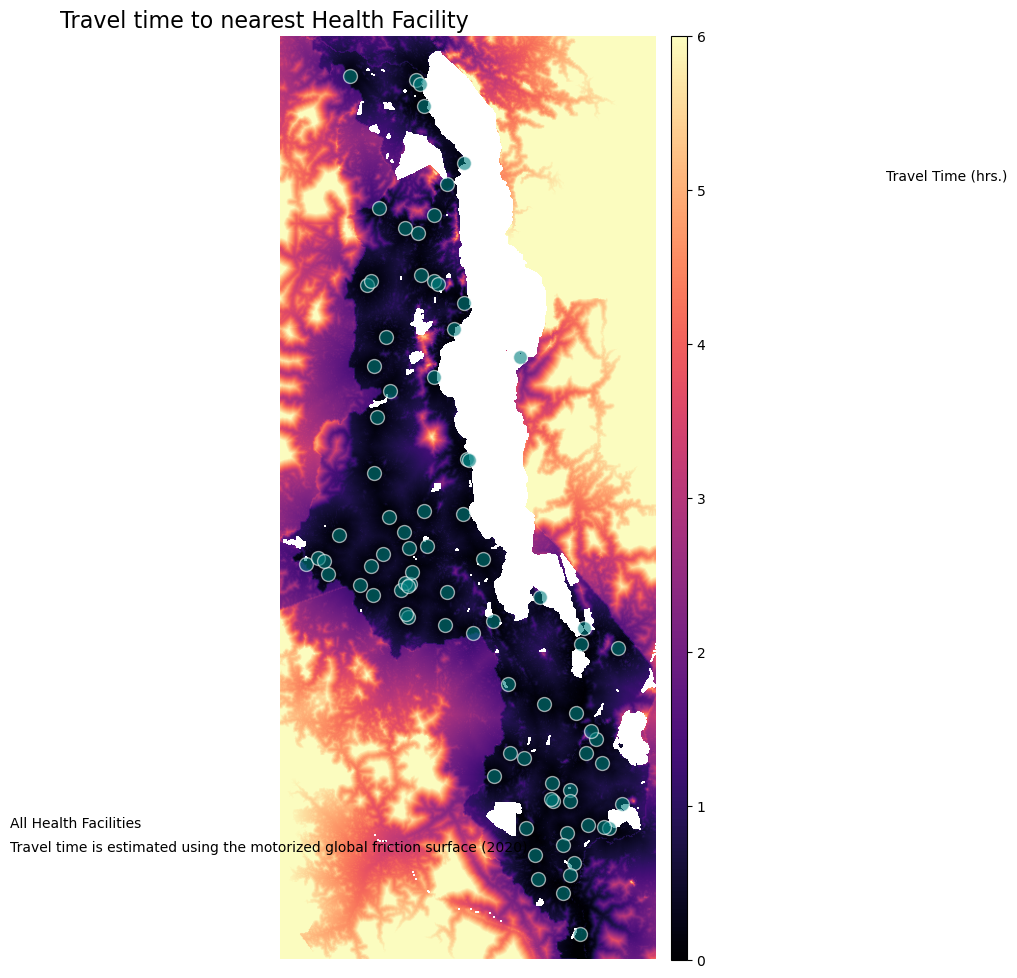

In [56]:
# Plot

figsize = (12, 12)
fig, ax = plt.subplots(1, 1,  figsize = figsize)
ax.set_title("Travel time to nearest Health Facility", fontsize=16, horizontalalignment='right')
plt.axis('off')
ext = plotting_extent(tt_rio)
im = ax.imshow(tt_rio.read(1), vmin=0, vmax=6, cmap='magma', extent=ext)
geodf_hf.plot(ax=ax, facecolor='teal', edgecolor='white', markersize=100, alpha=0.6)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs='EPSG:4326', zorder=-1)
txt="All Health Facilities"
txt2 = "Travel time is estimated using the motorized global friction surface (2020)"
plt.figtext(0.12, 0.22, txt, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.12, 0.2, txt2, wrap=True, horizontalalignment='left', fontsize=10)
plt.figtext(0.85, 0.76, "Travel Time (hrs.)", wrap=False, fontsize=10)
# plt.savefig("travel-time-friction.png", dpi=300, bbox_inches='tight', facecolor='white')